In [ ]:
import json
import pandas as pd

with open("../study_result.json") as f:
    data = json.load(f)
# Format the output of limesurvey to be loadable as a dataframe
df = pd.DataFrame(data["responses"])
# Looking at the DF, respondant 10 answered weqwe & qweqwe for job description and work exp. gets dropped. 
# Filter out empty responses

# Check for duplicates
#duplicates = df[df.duplicated(subset=["Q001[SQ001]. Über Sie: [Ihre Berufsbezeichnung:]", "Q001[SQ002]. Über Sie: [Berufserfahrung im Bereich Nephrologie in Jahren:]"], keep=False)]
#print(duplicates)
# -> leads to the following responder ids: [23, 36, 41, 26, 27, 24, 21, 29]
# 24 & 26 are failed answers of 27
# 21 is a failed response of 29
# 20 stopped in the middle of graft_rejection 
# 23, 36, 41 are completely empty
# -> 42 has low experience, awating feedback -> decided to keep him

#df[df["id. Response ID"].isin([23, 36, 41, 26, 27, 24, 21, 29])]

# 14, 30, 32 stopped answering after graft_rejection
# 38 stopped answering after graf_loss
# Drop them accordingly
invalid_responses = [10, 20, 23, 36, 41, 26, 24, 21]
df = df[~df["id. Response ID"].isin(invalid_responses)]
df


,id. Response ID,submitdate. Date submitted,lastpage. Last page,startlanguage. Start language,seed. Seed,startdate. Date started,datestamp. Date last action,Q001[SQ001]. Über Sie: [Ihre Berufsbezeichnung:],Q001[SQ002]. Über Sie: [Berufserfahrung im Bereich Nephrologie in Jahren:],Q00[SQ006]. Risikofaktoren für Transplantatabstossung [Geschlecht (Empfänger)],...,Q254324[SQ018]. Risikofaktoren für Tod des/der Patient/Patientin [Leukozyten im Blut],Q254324[SQ019]. Risikofaktoren für Tod des/der Patient/Patientin [C-reaktives Protein],Q254324[SQ020]. Risikofaktoren für Tod des/der Patient/Patientin [Proteinurie],Q254324[SQ021]. Risikofaktoren für Tod des/der Patient/Patientin [Albumin/Kreatinin-Verhältnis],Q254324[SQ022]. Risikofaktoren für Tod des/der Patient/Patientin [eGFR],Q254324[SQ023]. Risikofaktoren für Tod des/der Patient/Patientin [Tacrolimus-Dosis],Q254324[SQ024]. Risikofaktoren für Tod des/der Patient/Patientin [Methylprednisolon-Dosis],Q254324[SQ025]. Risikofaktoren für Tod des/der Patient/Patientin [Ciclosporin-Dosis],Q254324[SQ026]. Risikofaktoren für Tod des/der Patient/Patientin [Anzahl der Dialysesitzungen],Q402037. Haben Sie weitere Anmerkungen?
1,13,2026-01-27 10:34:18,3.0,en,1891270304,2026-01-27 10:26:46,2026-01-27 10:34:18,Ärztin,zwei Jahre,0,...,None,None,1,None,1,1,0,0,None,
2,14,None,1.0,en,1526181294,2026-01-27 11:59:42,2026-01-27 12:05:59,Nephrologin,10,0,...,None,None,None,None,None,None,None,None,None,None
3,16,2026-01-27 18:07:02,3.0,en,1871847294,2026-01-27 18:02:32,2026-01-27 18:07:02,Ärztin,11,0,...,None,None,None,1,None,None,None,1,1,
4,19,2026-01-29 13:33:55,3.0,en,347282149,2026-01-29 13:24:21,2026-01-29 13:33:55,Facharzt Innere Medizin,3,0,...,None,None,1,1,None,1,1,1,None,
7,22,2026-01-29 14:06:08,3.0,en,1323071953,2026-01-29 13:55:26,2026-01-29 14:06:08,Internistin/Nephrologin,13,0,...,None,None,1,1,None,1,1,1,None,Auch hier wird wieder von der Abstoßung gerede...
10,25,2026-02-06 11:28:50,3.0,en,535816072,2026-02-06 11:13:58,2026-02-06 11:28:50,Oberarzt,35,0,...,1,1,1,1,None,0,None,0,None,
12,27,2026-02-06 11:29:31,3.0,en,2025234497,2026-02-06 11:25:21,2026-02-06 11:29:31,Studienärztin,1,0,...,None,None,None,None,None,1,1,1,None,
13,28,2026-02-06 12:11:54,3.0,en,233969170,2026-02-06 11:59:09,2026-02-06 12:11:54,OÄ,8,0,...,None,None,1,1,1,1,1,1,0,
14,29,None,2.0,en,796438119,2026-02-09 11:12:19,2026-02-09 11:23:28,Arzt,15,0,...,0,None,1,1,None,1,1,1,1,
15,30,None,1.0,en,1641623453,2026-02-09 11:17:41,2026-02-09 11:23:21,Arzt,20,0,...,None,None,None,None,None,None,None,None,None,None


In [7]:
#Capture Study results for graft REJECTION
#complete_df = df[~df["id. Response ID"].isin([30,32,38])]
#q_df = complete_df.filter(regex=r"^Q(?!001).*\]") # Filter Columns so they Start with Q (e.g. a question) but exclude those that end on ? (Haben Sie weitere Anmerkungen?)
                                         # and those with Q ID 001 as that is metadata.

rejection_df = df
q_df = rejection_df.filter(regex=r"^Q(00\[|205144|700059)+.*\]")
q_df = q_df.astype("Int64")
yes_counts = q_df.sum().sort_values(ascending=False)
# Translation of Question IDs:
#{
#    "Q00": "Top 5 indicators graft rejection"
#    "Q205144": "Top 12 indicators graft rejection"
#    "Q700059": "Irrelevant for graft rejection?"
#    "Q995750": "Top 5 indicators graft loss"
#    "Q884437": "Top 12 indicators graft loss"
#    "Q62180": "Irrelevant for graft loss" -> was falsly called rejection during the survey, but represents loss
#    "Q513784": "Top 5 indicators mortality"
#    "Q363181": "Top 12 indicators mortality"
#    "Q254324": "Irrelevant for mortality"
#}
results = pd.DataFrame({'scenario': [], 'feature': [], 'value': []})
n = len(q_df)
i = 0
for k, v in yes_counts.items():
    id, text = k.split(".")
    scenario, feature = text.split("[")
    _, _, _, scenario, _ = scenario.split(" ")
    feature = feature[0:-1]
    #print(id, scenario, feature)
    new_key = None
    if "Q00" in id:
        new_key = f"Top-5 {scenario}: "
    elif "Q205144" in id:
        new_key = f"Top-12 {scenario}: "
    elif "Q700059" in id:
        new_key = f"Little relevance {scenario}: "
    if not new_key: continue

    results.loc[i] = [new_key, feature, ((v / n) * 100)]  # adding a row
    i+=1

graft_rejection_results_df = results.sort_values(by=["scenario", "value"], ascending=False)

In [8]:
#Capture Study results for graft LOSS
#complete_df = df[~df["id. Response ID"].isin([30,32,38])]
#q_df = complete_df.filter(regex=r"^Q(?!001).*\]") # Filter Columns so they Start with Q (e.g. a question) but exclude those that end on ? (Haben Sie weitere Anmerkungen?)
                                         # and those with Q ID 001 as that is metadata.

loss_df = df[~df["id. Response ID"].isin([30,32,14])]
q_df = loss_df.filter(regex=r"^Q(995750|884437|62180)+.*\]")
q_df = q_df.astype("Int64")
yes_counts = q_df.sum().sort_values(ascending=False)
# Translation of Question IDs:
#{
#    "Q00": "Top 5 indicators graft rejection"
#    "Q205144": "Top 12 indicators graft rejection"
#    "Q700059": "Irrelevant for graft rejection?"
#    "Q995750": "Top 5 indicators graft loss"
#    "Q884437": "Top 12 indicators graft loss"
#    "Q62180": "Irrelevant for graft loss" -> was falsly called rejection during the survey, but represents loss
#    "Q513784": "Top 5 indicators mortality"
#    "Q363181": "Top 12 indicators mortality"
#    "Q254324": "Irrelevant for mortality"
#}
results = pd.DataFrame({'scenario': [], 'feature': [], 'value': []})
n = len(q_df)
i = 0
for k, v in yes_counts.items():
    id, text = k.split(".")
    scenario, feature = text.split("[")
    _, _, _, scenario, _ = scenario.split(" ")
    feature = feature[0:-1]
    #print(id, scenario, feature)
    new_key = None
    if "Q995750" in id:
        new_key = f"Top-5 {scenario}: "
    elif "Q884437" in id:
        new_key = f"Top-12 {scenario}: "
    elif "Q62180" in id:
        new_key = f"Little relevance {scenario}: "
    if not new_key: continue

    results.loc[i] = [new_key, feature, ((v / n) * 100)]  # adding a row
    i+=1

graft_loss_results_df = results.sort_values(by=["scenario", "value"], ascending=False)
graft_loss_results_df

,scenario,feature,value
5,Top-5 Transplantatverlust:,eGFR,58.823529
8,Top-5 Transplantatverlust:,Serumkreatinin,52.941176
10,Top-5 Transplantatverlust:,Broad Antigen Mismatch (HLA-Inkompatibilität),52.941176
13,Top-5 Transplantatverlust:,Urinvolumen,52.941176
20,Top-5 Transplantatverlust:,Art der Spende (Lebend/Postmortal),41.176471
...,...,...,...
49,Little relevance Transplantatabstossung:,Albumin/Kreatinin-Verhältnis,11.764706
50,Little relevance Transplantatabstossung:,Urinvolumen,11.764706
53,Little relevance Transplantatabstossung:,Broad Antigen Mismatch (HLA-Inkompatibilität),11.764706
60,Little relevance Transplantatabstossung:,Alter (Empfänger),5.882353


In [9]:
#Capture Study results for MORTALITY
#complete_df = df[~df["id. Response ID"].isin([30,32,38])]
#q_df = complete_df.filter(regex=r"^Q(?!001).*\]") # Filter Columns so they Start with Q (e.g. a question) but exclude those that end on ? (Haben Sie weitere Anmerkungen?)
                                         # and those with Q ID 001 as that is metadata.

loss_df = df[~df["id. Response ID"].isin([30,32,14, 38])]
q_df = loss_df.filter(regex=r"^Q(513784|363181|254324)+.*\]")
q_df = q_df.astype("Int64")
yes_counts = q_df.sum().sort_values(ascending=False)

results = pd.DataFrame({'scenario': [], 'feature': [], 'value': []})
n = len(q_df)
i = 0
for k, v in yes_counts.items():
    id, text = k.split(".")
    scenario, feature = text.split("[")
    #_, _, _, scenario, _ = scenario.split(" ")
    scenario = "Mortality"
    feature = feature[0:-1]
    #print(id, scenario, feature)
    new_key = None
    if "Q513784" in id:
        new_key = f"Top-5 {scenario}: "
    elif "Q36318" in id:
        new_key = f"Top-12 {scenario}: "
    elif "Q254324" in id:
        new_key = f"Little relevance {scenario}: "
    if not new_key: continue

    results.loc[i] = [new_key, feature, ((v / n) * 100)]  # adding a row
    i+=1

mortality_results_df = results.sort_values(by=["scenario", "value"], ascending=False)

In [21]:
import numpy as np

def map_scores_to_relevance(s):
    sorted_scores = sorted(s, key=lambda x: x[1], reverse=True)
    scores = np.array([v for _, v in sorted_scores])
    n = len(scores)

    # Step 1: Quantile index boundaries
    quantile_indices = [
        int(n * 0.2),
        int(n * 0.4),
        int(n * 0.6),
        int(n * 0.8)
    ]

    # Step 2: Compute score differences
    diffs = scores[:-1] - scores[1:]

    # Step 3: Adjust each quantile boundary using largest local drop
    final_boundaries = []
    window = int(n * 0.1)  # search ±10% around quantile

    for q_idx in quantile_indices:
        start = max(0, q_idx - window)
        end = min(len(diffs), q_idx + window)

        if start >= end:
            final_boundaries.append(q_idx)
            continue

        local_diffs = diffs[start:end]
        local_max_index = np.argmax(local_diffs) + start
        final_boundaries.append(local_max_index + 1)

    final_boundaries = sorted(set(final_boundaries))

    # Step 4: Assign bins
    relevance_map = {}
    current_bin = 1
    boundary_pointer = 0

    for i, (k, v) in enumerate(sorted_scores):
        if boundary_pointer < len(final_boundaries) and i >= final_boundaries[boundary_pointer]:
            current_bin += 1
            boundary_pointer += 1

        relevance_map[german_to_english[k]] = min(current_bin, 5)
    return relevance_map


task_result = {}
task_score = {}  
german_to_english = {
    "Alter (Empfänger)": "Age",
    "Geschlecht (Empfänger)": "gender",
    "Grunderkrankung, die zur Nierenschädigung geführt hat": "underlying_disease",
    "Blutgruppe (Empfänger)": "blood_group",
    "Kalte Ischämiezeit": "cold_ischemia_time",
    "Geschlecht (Spender)": "gender_donor",
    "Alter (Spender)": "age_donor",
    "Blutgruppe (Spender)": "donor_bloodgroup",
    "Art der Spende (Lebend/Postmortal)": "type_of_donation",
    "PIRCHE-Score": "pirche_score",
    "Broad Antigen Mismatch (HLA-Inkompatibilität)": "mm_broad",
    "Herzfrequenz": "Heart rate",
    "Blutdruck": "Blood pressure",
    "Gewicht": "weight",
    "Temperatur": "Temperature",
    "Urinvolumen": "urine_volume",
    "Serumkreatinin": "Creatinine",
    "Leukozyten im Blut": "Leukocyte",
    "C-reaktives Protein": "C-reactive protein",
    "Proteinurie": "Proteinuria",
    "Albumin/Kreatinin-Verhältnis": "acr",
    "eGFR": "eGFR",
    "Tacrolimus-Dosis": "Tacrolimus",
    "Methylprednisolon-Dosis": "Methylprednisolon",
    "Ciclosporin-Dosis": "Ciclosporin",
    "Anzahl der Dialysesitzungen": "number_dialyses",
    "Körpertemperatur/Fieber": "Temperature"
}

for task in ["Graft Loss", "Rejection", "Mortality"]:
    if task == "Graft Loss": d = graft_loss_results_df # Select dataframe
    if task == "Rejection": d = graft_rejection_results_df # Select dataframe
    if task == "Mortality": d = mortality_results_df # Select dataframe
    features = d["feature"].unique().tolist()
    relevance_scores = {k:0 for k in features}
    for f in features:
       x =  d[d["feature"].isin([f])]
       y = x["value"]
       i = 1
       for p in y:
          #print(f, p)
          relevance_scores[f] += p*i
          i -= 0.33
    #print(relevance_scores)
    task_score[task] = relevance_scores
    #sorted_scores = sorted(relevance_scores.items(), key=lambda item: item[1], reverse=True)
    #relevance_map = {}
    #relevance = 6
    ##for i, (k, v) in enumerate(sorted_scores):
    ##   # likert scale: 5 - irrrelevant - 4 least relevant - 3 relevant - 2 very relevance - 1 Most Relevant
    ##   if i % 5 == 0:
    ##      relevance-=1
    ##   relevance_map[german_to_english[k]] = relevance
    #
    #scores = [v for _, v in sorted_scores]
    #
    ## Compute differences between consecutive scores
    #diffs = [scores[i] - scores[i+1] for i in range(len(scores)-1)]
    #
    ## Get indices of the 4 largest drops
    ## These will define the borders between 5 bins
    #border_indices = sorted(range(len(diffs)), key=lambda i: diffs[i], reverse=True)
    #
    #print(border_indices)
    #
    #border_indices = sorted(border_indices[:4])
    ## Assign bins
    #relevance_map = {}
    #current_bin = 1  # 1 = Most Relevant
    #border_pointer = 0
    #for i, (k, v) in enumerate(sorted_scores):
    #
    #    # Move to next bin if we passed a border
    #    if border_pointer < len(border_indices) and i > border_indices[border_pointer]:
    #        current_bin += 1
    #        border_pointer += 1
    #
    #    # Clamp in case of edge effects
    #    current_bin = min(current_bin, 5)
    #
    #    relevance_map[german_to_english[k]] = current_bin
    
    #print(relevance_map)
    #print(relevance_scores)
    relevance_map = map_scores_to_relevance(relevance_scores.items())
    task_result[task] = relevance_map
print(task_result)

{'Graft Loss': {'eGFR': 1, 'Creatinine': 1, 'urine_volume': 1, 'mm_broad': 1, 'type_of_donation': 2, 'acr': 2, 'Proteinuria': 2, 'cold_ischemia_time': 2, 'Tacrolimus': 2, 'age_donor': 2, 'Age': 2, 'pirche_score': 3, 'weight': 3, 'Ciclosporin': 3, 'C-reactive protein': 3, 'Blood pressure': 4, 'blood_group': 4, 'Methylprednisolon': 4, 'donor_bloodgroup': 4, 'number_dialyses': 4, 'Leukocyte': 5, 'Temperature': 5, 'gender_donor': 5, 'gender': 5, 'Heart rate': 5}, 'Rejection': {'mm_broad': 1, 'Creatinine': 1, 'urine_volume': 1, 'cold_ischemia_time': 1, 'type_of_donation': 1, 'Tacrolimus': 1, 'Proteinuria': 1, 'eGFR': 2, 'Age': 2, 'acr': 3, 'pirche_score': 3, 'age_donor': 3, 'blood_group': 3, 'gender': 3, 'Methylprednisolon': 3, 'Ciclosporin': 3, 'donor_bloodgroup': 3, 'C-reactive protein': 4, 'weight': 4, 'gender_donor': 4, 'Temperature': 4, 'Leukocyte': 5, 'number_dialyses': 5, 'Blood pressure': 5, 'Heart rate': 5}, 'Mortality': {'Age': 1, 'Blood pressure': 1, 'C-reactive protein': 1, 'Tem

[{'feature': 'Age (recipient)', 'original_feature': 'Age', 'shap_value': 59.11764705882352, 'clinical_rating': 2}, {'feature': 'Blood pressure', 'original_feature': 'Blood pressure', 'shap_value': 33.705882352941174, 'clinical_rating': 4}, {'feature': 'C-Reactive protein', 'original_feature': 'C-reactive protein', 'shap_value': 39.647058823529406, 'clinical_rating': 3}, {'feature': 'Temperature', 'original_feature': 'Temperature', 'shap_value': 25.882352941176464, 'clinical_rating': 5}, {'feature': 'Heart rate', 'original_feature': 'Heart rate', 'shap_value': 13.999999999999995, 'clinical_rating': 5}, {'feature': 'Leukocyte', 'original_feature': 'Leukocyte', 'shap_value': 27.941176470588232, 'clinical_rating': 5}, {'feature': 'Creatinine', 'original_feature': 'Creatinine', 'shap_value': 82.52941176470588, 'clinical_rating': 1}, {'feature': 'Type of donation', 'original_feature': 'type_of_donation', 'shap_value': 70.88235294117646, 'clinical_rating': 2}, {'feature': 'Age (donor)', 'orig

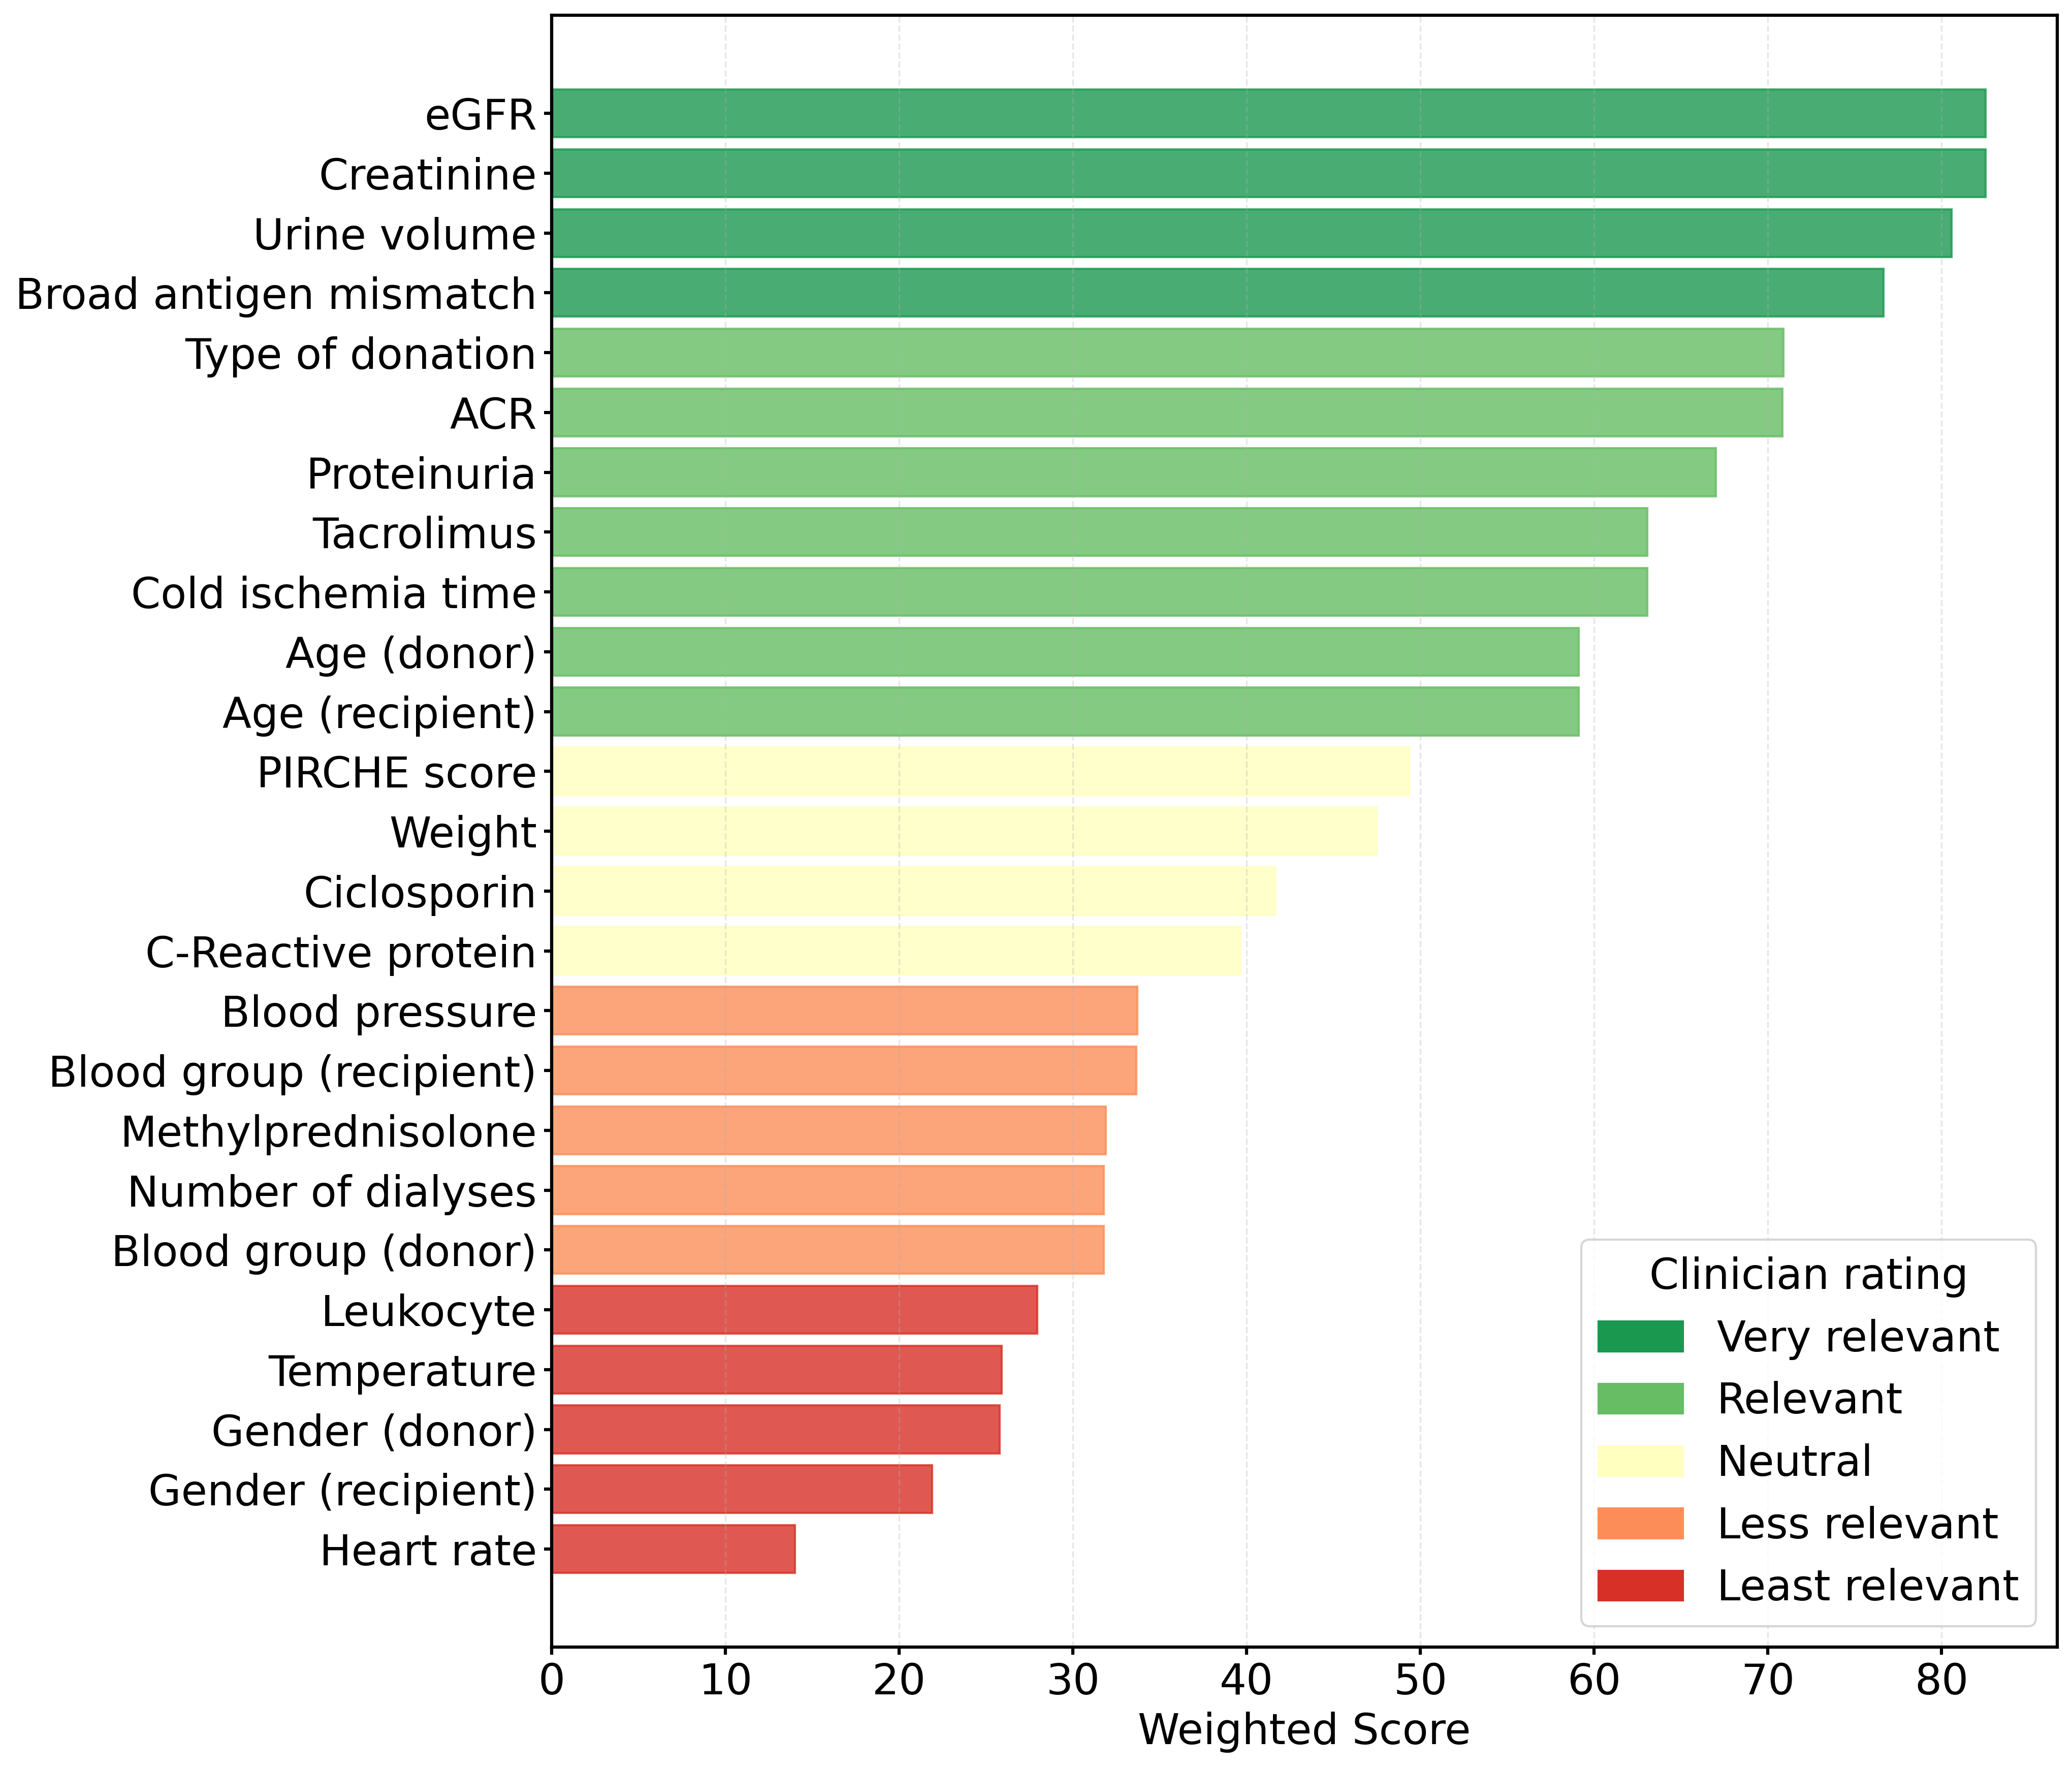


Graft Loss Feature Importance Comparison:
Feature | Score | Clinical Rating
--------------------------------------------------
eGFR | 82.5294 | Very relevant
Creatinine | 82.5294 | Very relevant
Urine volume | 80.5882 | Very relevant
Broad antigen mismatch | 76.6471 | Very relevant
Type of donation | 70.8824 | Relevant
ACR | 70.8235 | Relevant
Proteinuria | 67.0000 | Relevant
Tacrolimus | 63.0588 | Relevant
Cold ischemia time | 63.0588 | Relevant
Age (donor) | 59.1176 | Relevant
Age (recipient) | 59.1176 | Relevant
PIRCHE score | 49.3529 | Neutral
Weight | 47.4706 | Neutral
Ciclosporin | 41.6471 | Neutral
C-Reactive protein | 39.6471 | Neutral
Blood pressure | 33.7059 | Less relevant
Blood group (recipient) | 33.6471 | Less relevant
Methylprednisolone | 31.8824 | Less relevant
Number of dialyses | 31.7647 | Less relevant
Blood group (donor) | 31.7647 | Less relevant
Leukocyte | 27.9412 | Least relevant
Temperature | 25.8824 | Least relevant
Gender (donor) | 25.7647 | Least relevant
Ge

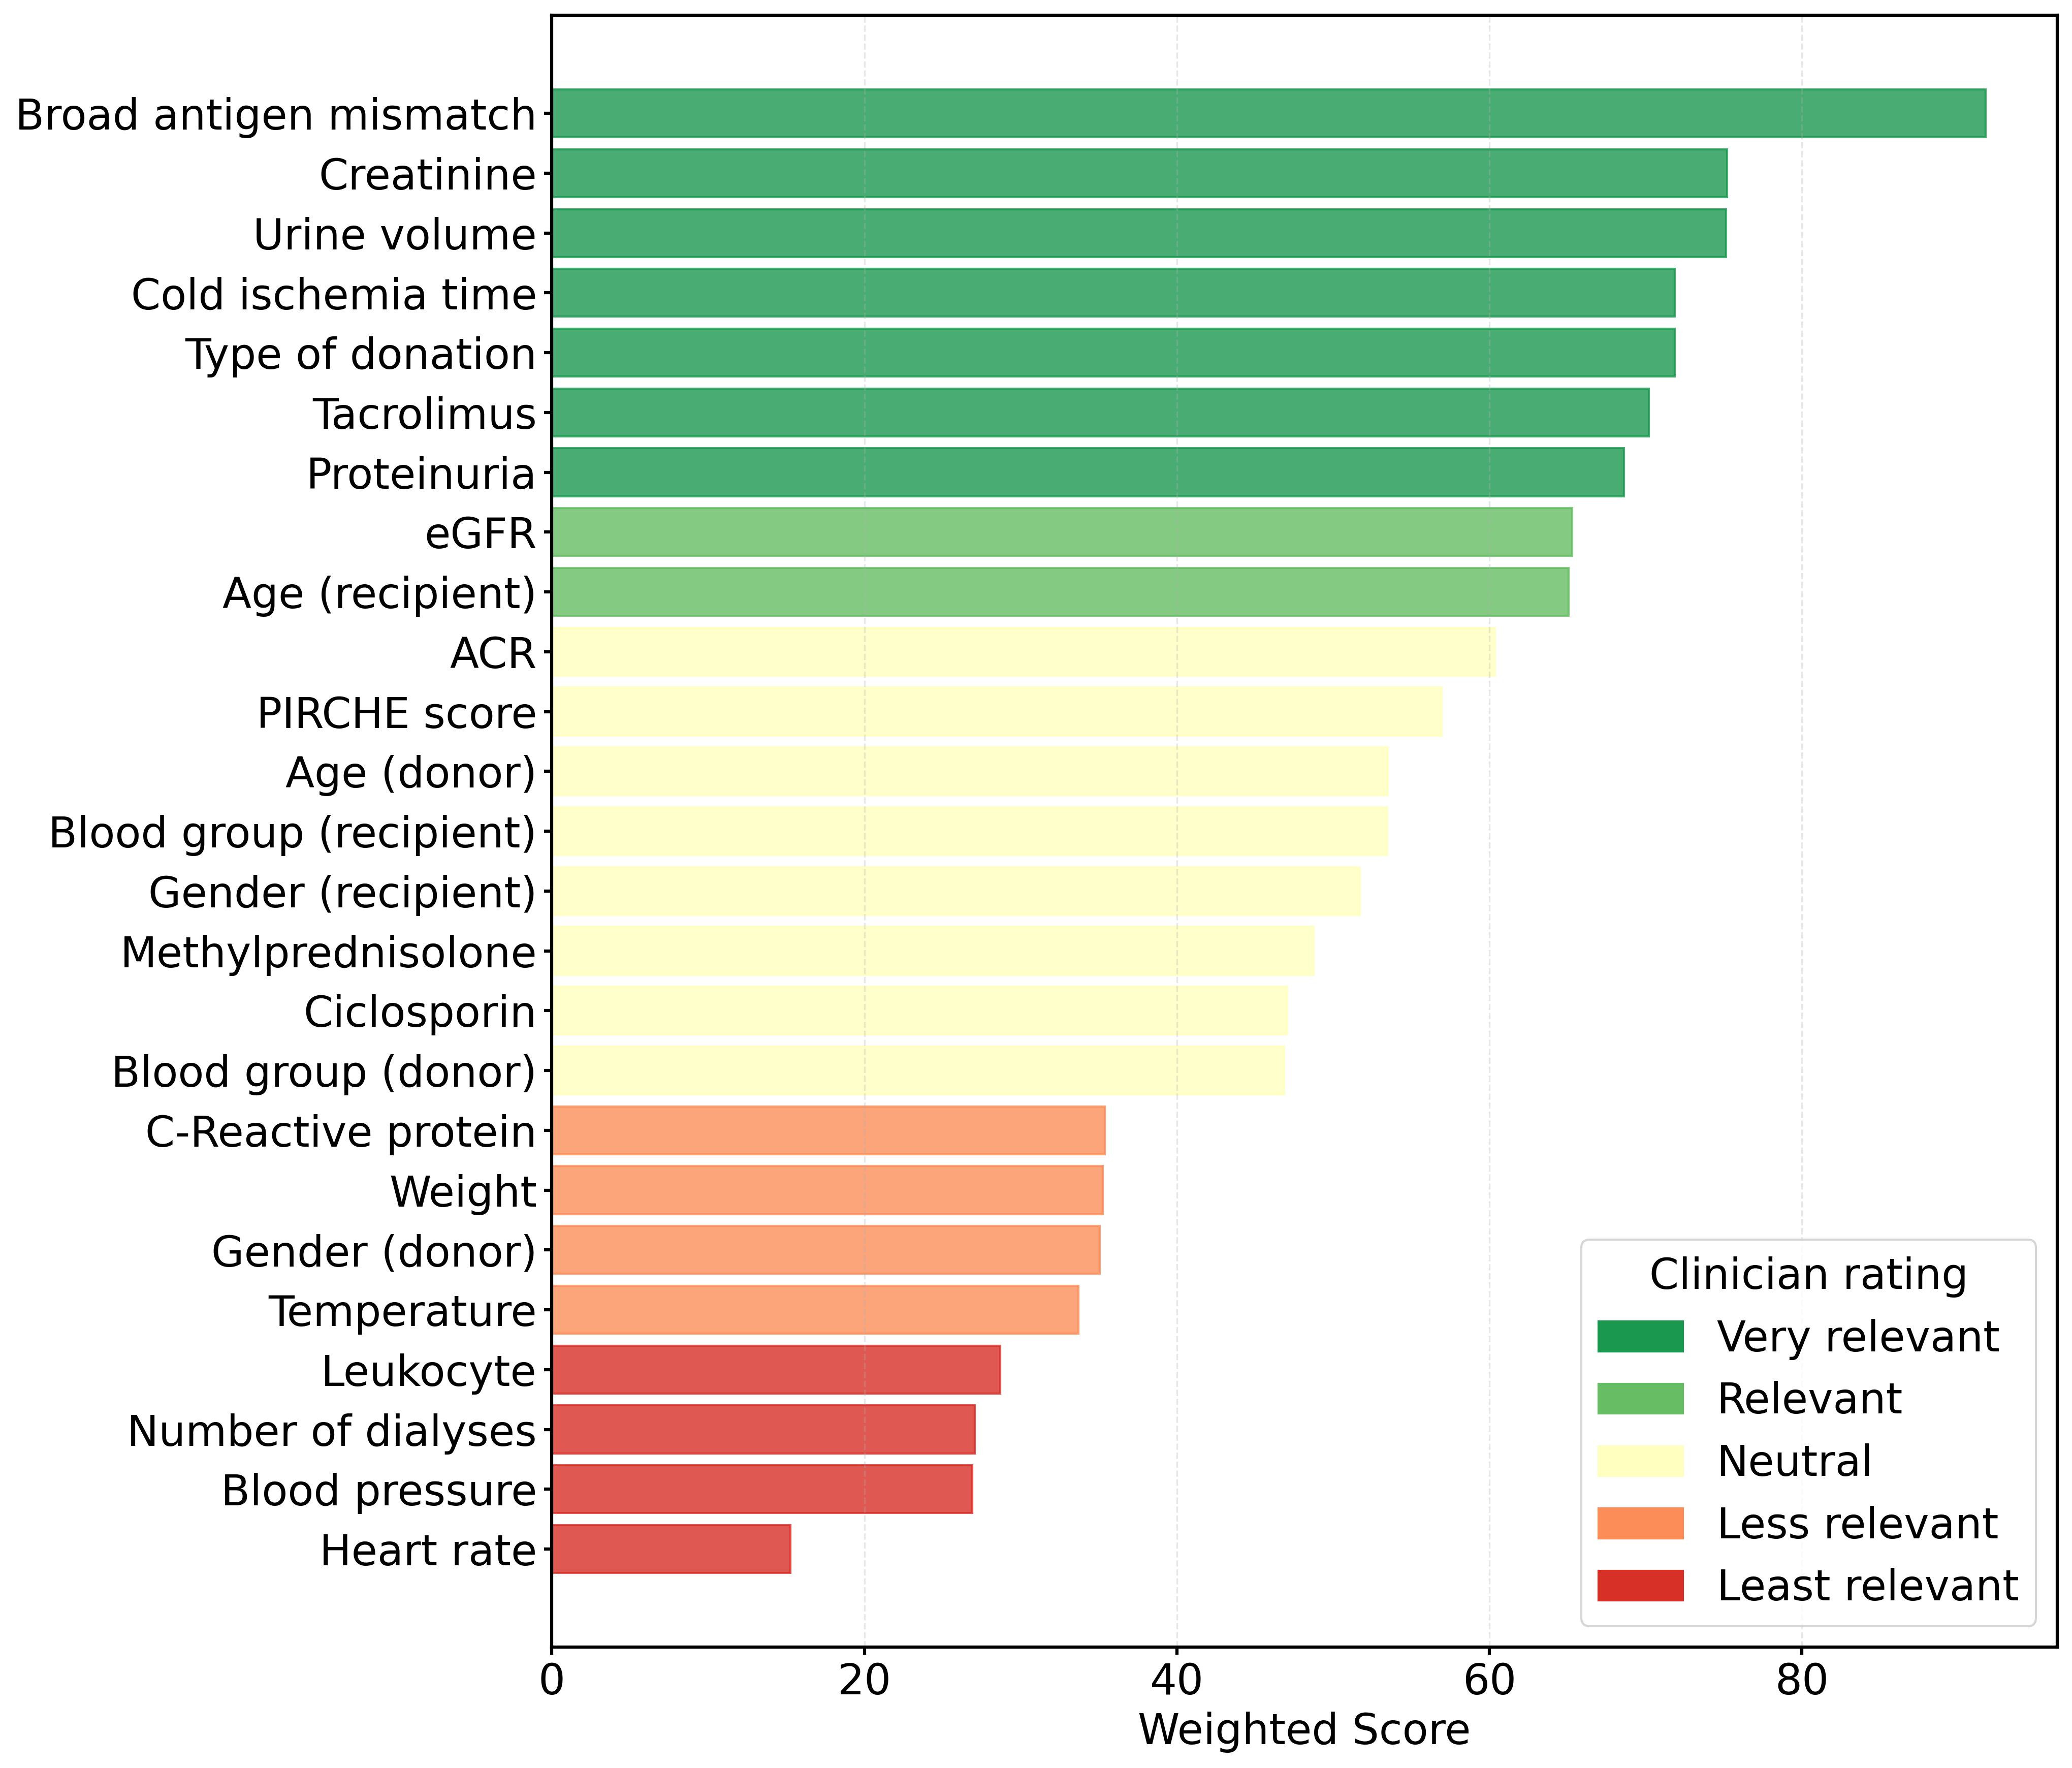


Rejection Feature Importance Comparison:
Feature | Score | Clinical Rating
--------------------------------------------------
Broad antigen mismatch | 91.7500 | Very relevant
Creatinine | 75.2000 | Very relevant
Urine volume | 75.1500 | Very relevant
Cold ischemia time | 71.8500 | Very relevant
Type of donation | 71.8500 | Very relevant
Tacrolimus | 70.2000 | Very relevant
Proteinuria | 68.6000 | Very relevant
eGFR | 65.3000 | Relevant
Age (recipient) | 65.0500 | Relevant
ACR | 60.3500 | Neutral
PIRCHE score | 56.9500 | Neutral
Age (donor) | 53.5000 | Neutral
Blood group (recipient) | 53.4500 | Neutral
Gender (recipient) | 51.7000 | Neutral
Methylprednisolone | 48.7500 | Neutral
Ciclosporin | 47.0500 | Neutral
Blood group (donor) | 46.8500 | Neutral
C-Reactive protein | 35.4000 | Less relevant
Weight | 35.2500 | Less relevant
Gender (donor) | 35.0500 | Less relevant
Temperature | 33.7000 | Less relevant
Leukocyte | 28.7000 | Least relevant
Number of dialyses | 27.0500 | Least relevant

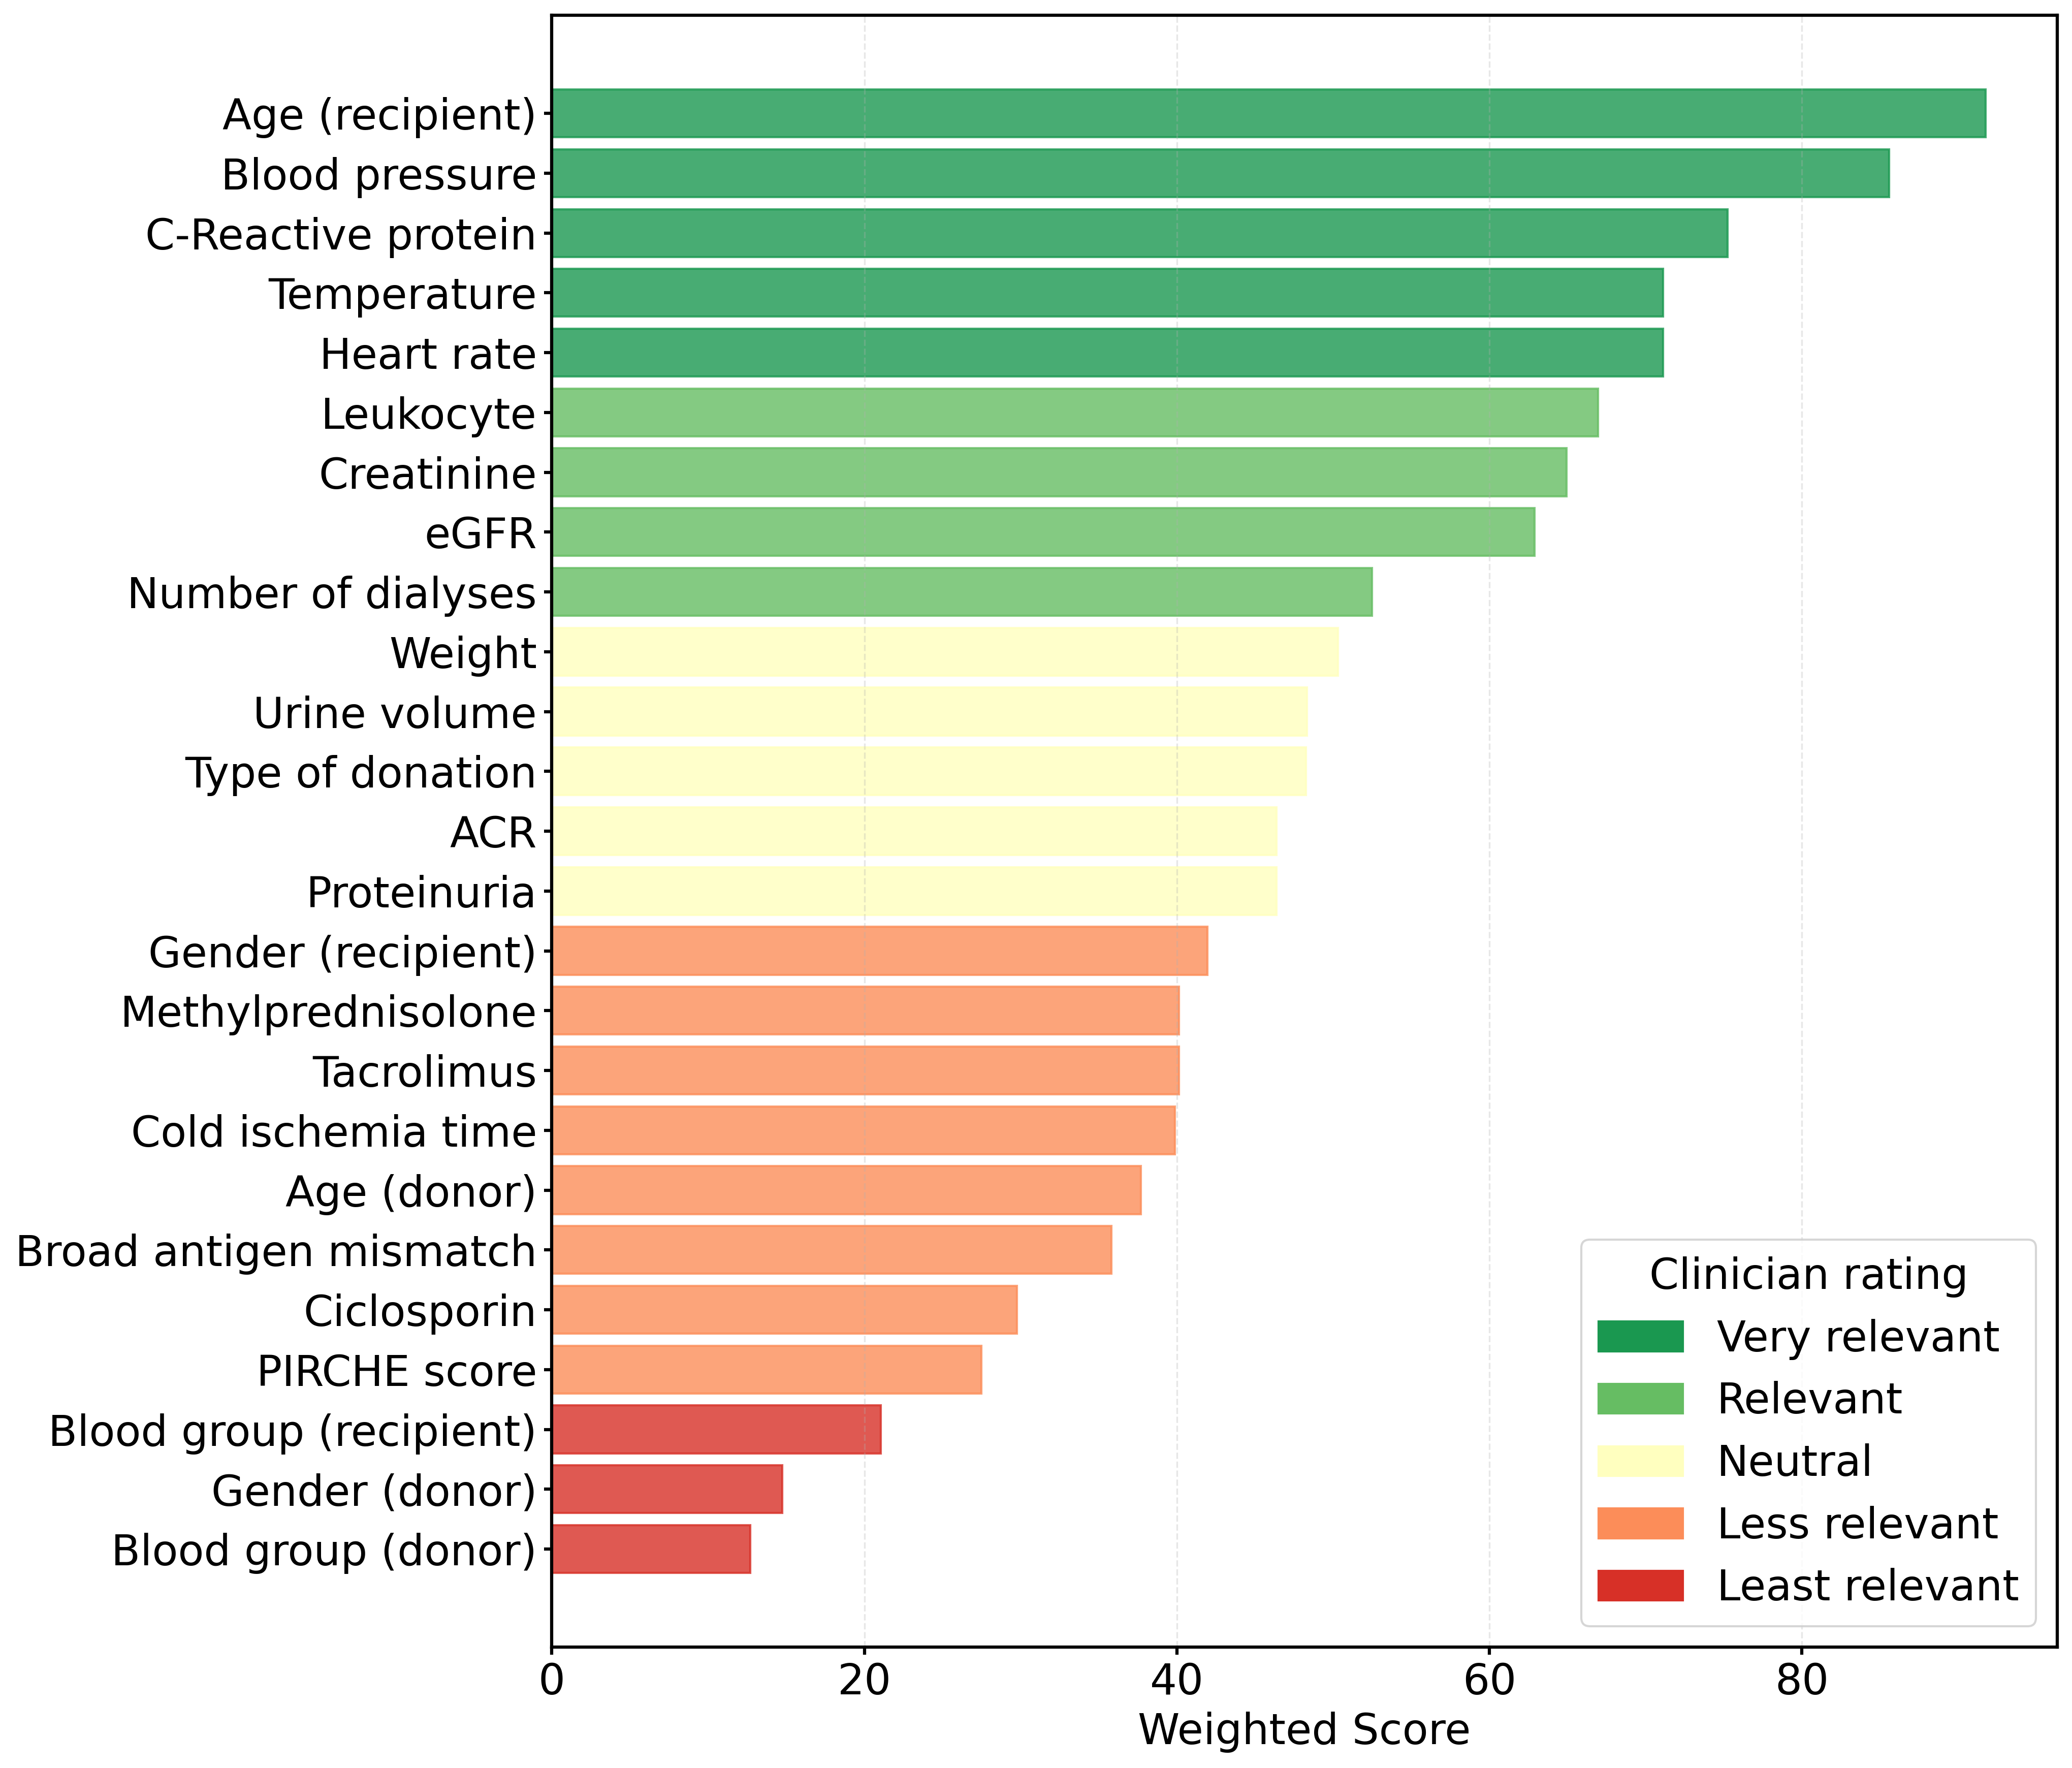


Mortality Feature Importance Comparison:
Feature | Score | Clinical Rating
--------------------------------------------------
Age (recipient) | 91.7500 | Very relevant
Blood pressure | 85.5625 | Very relevant
C-Reactive protein | 75.2500 | Very relevant
Temperature | 71.1250 | Very relevant
Heart rate | 71.1250 | Very relevant
Leukocyte | 66.9375 | Relevant
Creatinine | 64.9375 | Relevant
eGFR | 62.8750 | Relevant
Number of dialyses | 52.5000 | Relevant
Weight | 50.3125 | Neutral
Urine volume | 48.3125 | Neutral
Type of donation | 48.2500 | Neutral
ACR | 46.3750 | Neutral
Proteinuria | 46.3750 | Neutral
Gender (recipient) | 41.9375 | Less relevant
Methylprednisolone | 40.1250 | Less relevant
Tacrolimus | 40.1250 | Less relevant
Cold ischemia time | 39.8750 | Less relevant
Age (donor) | 37.6875 | Less relevant
Broad antigen mismatch | 35.8125 | Less relevant
Ciclosporin | 29.7500 | Less relevant
PIRCHE score | 27.5000 | Less relevant
Blood group (recipient) | 21.0625 | Least relevant
G

In [22]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.colors as mcolors


# Set global font sizes
plt.rcParams.update({
    'font.size': 20,              # Base font size
    'axes.titlesize': 20,         # Title font size
    'axes.labelsize': 20,         # Axes label font size
    'xtick.labelsize': 20,        # X-tick label font size
    'ytick.labelsize': 20,        # Y-tick label font size
    'legend.fontsize': 20,        # Legend font size
    'figure.titlesize': 20,       # Figure title size
    'figure.dpi': 300,            # Figure DPI for high resolution
    'savefig.dpi': 300            # Save figure DPI
})

# Make lines thicker
plt.rcParams['lines.linewidth'] = 2.5
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['xtick.major.width'] = 1.5
plt.rcParams['ytick.major.width'] = 1.5

# Increase marker size default
plt.rcParams['lines.markersize'] = 8



# Define the translated Likert scale
likert_scale = {
    1: "Very relevant",
    2: "Relevant",
    3: "Neutral",
    4: "Less relevant",
    5: "Least relevant"
}

# Define a color map for clinical ratings
colors = ['#1a9850', '#66bd63', '#ffffbf', '#fc8d59', '#d73027']  # Green to Red
rating_cmap = mcolors.ListedColormap(colors)

# Create a mapping dictionary for feature name formatting
feature_name_mapping = {
    'Age': 'Age (recipient)',
    'gender': 'Gender (recipient)',
    'underlying_disease': 'Underlying disease',
    'blood_group': 'Blood group (recipient)',
    'cold_ischemia_time': 'Cold ischemia time',
    'gender_donor': 'Gender (donor)',
    'age_donor': 'Age (donor)',
    'donor_bloodgroup': 'Blood group (donor)',
    'type_of_donation': 'Type of donation',
    'pirche_score': 'PIRCHE score',
    'mm_broad': 'Broad antigen mismatch',
    'Heart rate': 'Heart rate',
    'hr': 'Heart rate',
    'Blood pressure': 'Blood pressure',
    'bp_sys': 'Systolic blood pressure',
    'bp_dia': 'Diastolic blood pressure',
    'weight': 'Weight',
    'Temperature': 'Temperature',
    'temperature': 'Temperature',
    'urine_volume': 'Urine volume',
    'Creatinine': 'Creatinine',
    'Leukocyte': 'Leukocyte',
    'C-reactive protein': 'C-Reactive protein',
    'crphp': 'C-Reactive protein',
    'Proteinuria': 'Proteinuria',
    'acr': 'ACR',
    'ACR': 'ACR',
    'eGFR': 'eGFR',
    'Tacrolimus': 'Tacrolimus',
    'Methylprednisolon': 'Methylprednisolone',
    'Ciclosporin': 'Ciclosporin',
    'number_dialyses': 'Number of dialyses',
    'diuresis_time': 'Diuresis time',
    'Notes embeddings': 'Notes embeddings',
    'Underlying disease': 'Underlying disease'
}

# Function to create a comparison plot for each task
def create_comparison_plot(task, shap_data, task_data, features):
    # Match features between datasets (handling case sensitivity)
    matched_data = []
    
    for feature in features:
        # Find corresponding feature in SHAP data (case-insensitive)
        shap_key = None
        for k in shap_data.keys():
            if german_to_english[k].lower() == feature.lower():
                shap_key = k
                break
        
        if shap_key:
            # Use the proper English name for the feature
            proper_name = feature_name_mapping.get(feature, feature)
            
            matched_data.append({
                'feature': proper_name,
                'original_feature': feature,
                'shap_value': shap_data[shap_key],
                'clinical_rating': task_data[feature]
            })
    print(matched_data)
    # Convert to DataFrame and sort by SHAP value
    df = pd.DataFrame(matched_data)
    df = df.sort_values('shap_value', ascending=True)  # Ascending for horizontal bars
    
    # Invert clinical ratings for correlation calculation (since 1=important, 5=unimportant)
    inverted_clinical = [6 - rating for rating in df['clinical_rating']]
    
    # Calculate Spearman correlation
    corr, p_value = stats.spearmanr(df['shap_value'], inverted_clinical)
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(14, 12))
    
    # Create horizontal bar chart of SHAP values
    bars = ax.barh(df['feature'], df['shap_value'], align='center', alpha=0.8)
    
    # Color the bars according to clinical rating
    for i, (bar, rating) in enumerate(zip(bars, df['clinical_rating'])):
        bar.set_color(colors[rating-1])
        
        # Add clinical rating text next to each bar
        #ax.text(bar.get_width() + 0.001, i, f"  {likert_scale[rating]}", va='center', fontsize=10)
    
    # Set axis labels and title
    ax.set_xlabel('Weighted Score')
    #ax.set_title(f"{task}: Model vs Clinical Feature Importance\nSpearman ρ = {corr:.3f} (p = {p_value:.3f})", pad=20)
    
    # Adjust tick label font size
    ax.tick_params(axis='y')
    
    # Add legend for clinical ratings
    legend_elements = [plt.Rectangle((0, 0), 1, 1, color=colors[i-1], label=likert_scale[i]) for i in range(1, 6)]
    ax.legend(handles=legend_elements, loc='lower right', title="Clinician rating")
    
    # Add grid to make it easier to read
    ax.grid(True, linestyle='--', alpha=0.3, axis='x')
    
    plt.tight_layout()
    return fig, corr, p_value, df

# Process each task
tasks = ["Graft Loss", "Rejection", "Mortality"]
eng_features = [german_to_english[k] for k in features]
for task in tasks:
    fig, corr, p_value, data = create_comparison_plot(task, task_score[task], task_result[task], eng_features)
    plt.savefig(f"../plots/{task.replace(' ', '_')}_feature_importance_clinicians.jpg", dpi=300, bbox_inches="tight")
    plt.show()
    
    # Print table of results for this task
    print(f"\n{task} Feature Importance Comparison:")
    print("Feature | Score | Clinical Rating")
    print("-" * 50)
    for _, row in data.sort_values('shap_value', ascending=False).iterrows():
        print(f"{row['feature']} | {row['shap_value']:.4f} | {likert_scale[row['clinical_rating']]}")